In [2]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm


# feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURE_ENGINEERING.features import *
from MODELS.xgboostModel import *

In [3]:
pd.set_option('display.max_columns', None)
eplison = 1e-8

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s19['EXPECTED_USAGE_MIN'] = s19['USG_PCT_ROLLING_AVG_5'] * (s19['MIN_ROLLING_AVG_5'] + eplison)

s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s20['EXPECTED_USAGE_MIN'] = s20['USG_PCT_ROLLING_AVG_5'] * (s20['MIN_ROLLING_AVG_5'] + eplison)

s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s21['EXPECTED_USAGE_MIN'] = s21['USG_PCT_ROLLING_AVG_5'] * (s21['MIN_ROLLING_AVG_5'] + eplison)

s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s22['EXPECTED_USAGE_MIN'] = s22['USG_PCT_ROLLING_AVG_5'] * (s22['MIN_ROLLING_AVG_5'] + eplison)

s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s23['EXPECTED_USAGE_MIN'] = s23['USG_PCT_ROLLING_AVG_5'] * (s23['MIN_ROLLING_AVG_5'] + eplison)

s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s24['EXPECTED_USAGE_MIN'] = s24['USG_PCT_ROLLING_AVG_5'] * (s24['MIN_ROLLING_AVG_5'] + eplison)

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s25['EXPECTED_USAGE_MIN'] = s25['USG_PCT_ROLLING_AVG_5'] * (s25['MIN_ROLLING_AVG_5'] + eplison)

train_df = pd.concat([s19,s20,s21,s22,s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df

Training data shape: (123279, 1785)
Training date range: 2018-10-17 to 2023-04-09
Validation data shape: (26357, 1752)
Validation date range: 2023-10-25 to 2024-04-14
Test data shape: (26264, 1752)
Test date range: 2024-10-23 to 2025-04-13


Unnamed: 0  Unnamed: 0.2        PLAYER_NAME  PLAYER_ID    MATCHUP  \
0               0          47.0           Alex Len     203458  ATL @ NYK   
1               1          49.0     Alex Poythress    1627816  ATL @ NYK   
2               2          48.0    DeAndre' Bembry    1627761  ATL @ NYK   
3               3          90.0       Jaylen Adams    1629121  ATL @ NYK   
4               4          87.0         Jeremy Lin     202391  ATL @ NYK   
...           ...           ...                ...        ...        ...   
25872       25872           NaN        Jalen Duren    1631105  DET @ LAC   
25873       25873           NaN      Kevin Knox II    1628995  DET @ LAC   
25874       25874           NaN      Killian Hayes    1630165  DET @ LAC   
25875       25875           NaN  Marvin Bagley III    1628963  DET @ LAC   
25876       25876           NaN         Saddiq Bey    1630180  DET @ LAC   

      TEAM_ABBREVIATION     TEAM_ID OPP_ABBREVIATION  HOME_GAME   GAME_ID  \
0                   ATL  1610612737              NYK          0  21800007   
1                   ATL  1610612737              NYK          0  21800007   
2                   ATL  1610612737              NYK          0  21800007   
3                   ATL  1610612737              NYK          0  21800007   
4                   ATL  1610612737              NYK          0  21800007   
...                 ...         ...              ...        ...       ...   
25872               DET  1610612765              LAC          0  22200223   
25873               DET  1610612765              LAC          0  22200223   
25874               DET  1610612765              LAC          0  22200223   
25875               DET  1610612765              LAC          0  22200223   
25876               DET  1610612765              LAC          0  22200223   

        GAME_DATE WL  PTS  AST  REB  FGM  FGA  FG_PCT  FG3M  FG3A  FG3_PCT  \
0      2018-10-17  L    7    2    4    3    6   0.500     0     2    0.000   
1      2018-10-17  L    9    0    2    4    8   0.500     1     3    0.333   
2      2018-10-17  L    2    4    4    1    4   0.250     0     0      NaN   
3      2018-10-17  L    0    1    1    0    1   0.000     0     1    0.000   
4      2018-10-17  L    8    1    5    3    6   0.500     0     2    0.000   
...           ... ..  ...  ...  ...  ...  ...     ...   ...   ...      ...   
25872  2022-11-17  L    8    0    9    3    6   0.500     0     0      NaN   
25873  2022-11-17  L    3    0    2    1    4   0.250     1     3    0.333   
25874  2022-11-17  L    5    1    3    1    8   0.125     0     2    0.000   
25875  2022-11-17  L    4    0    8    1    5   0.200     0     1    0.000   
25876  2022-11-17  L   11    2    8    4   11   0.364     2     8    0.250   

       FTM  FTA  FT_PCT  OREB  DREB  STL  BLK  TOV  PLUS_MINUS  FANTASY_PTS  \
0        1    2   0.500     2     2    0    1    3         -14         14.8   
1        0    1   0.000     1     1    1    0    3         -21         11.4   
2        0    0     NaN     0     4    2    0    2         -12         16.8   
3        0    0     NaN     0     1    0    0    0           4          2.7   
4        2    2   1.000     0     5    1    0    2          -5         16.5   
...    ...  ...     ...   ...   ...  ...  ...  ...         ...          ...   
25872    2    3   0.667     4     5    0    1    1           6         20.8   
25873    0    0     NaN     1     1    1    2    0           6         14.4   
25874    3    4   0.750     0     3    3    2    1         -17         24.1   
25875    2    2   1.000     2     6    0    0    2         -12         11.6   
25876    1    1   1.000     2     6    1    0    1          -8         25.6   

       POINT_PER_SHOT       EFG START_POSITION  COMMENT  OFF_RATING  \
0               1.017  0.500000              C      NaN        92.3   
1               1.066  0.562500            NaN      NaN        68.0   
2               0.500  0.250000            NaN      NaN        80.7   

In [4]:
newFeatures = test_df.columns[test_df.columns.tolist().index('STARTING'):].tolist()
df_subset = test_df[newFeatures]
df_subset

STARTING  BLOWOUT_RISK  TEAM_IMPLIED_PTS_FAV  TEAM_IMPLIED_PTS_UND  \
0             0             0                 115.5                 108.0   
1             1             0                 115.5                 108.0   
2             1             0                 115.5                 108.0   
3             1             0                 115.5                 108.0   
4             1             0                 115.5                 108.0   
...         ...           ...                   ...                   ...   
26259         1             1                 106.0                 119.5   
26260         0             1                 106.0                 119.5   
26261         0             1                 106.0                 119.5   
26262         0             1                 106.0                 119.5   
26263         1             1                 106.0                 119.5   

       HEIGHT  WEIGHT  GUARD  FORWARD  CENTER  TEAM_DAYS_REST  \
0          77   225.0      1        0       0             0.0   
1          82   256.0      0        0       1             3.0   
2          80   221.0      1        1       0             0.0   
3          79   199.0      1        0       0             0.0   
4          80   219.0      0        1       0             0.0   
...       ...     ...    ...      ...     ...             ...   
26259      77   211.0      1        1       0             0.0   
26260      81   240.0      0        1       0             0.0   
26261      78   210.0      1        1       0             0.0   
26262      81   185.0      0        1       0             0.0   
26263      78   195.0      1        0       0             0.0   

       PLAYER_DAYS_REST  TEAM_B2B  IS_BACK_TO_BACK  PLAYER_MISSED_LAST  \
0                   3.0         1                0                   1   
1                   3.0         0                0                   0   
2                   3.0         1                0                   1   
3                   3.0         1                0                   1   
4                   3.0         1                0                   1   
...                 ...       ...              ...                 ...   
26259               3.0         1                0                   1   
26260               3.0         1                0                   1   
26261               3.0         1                0                   1   
26262               4.0         1                0                   1   
26263               3.0         1                0                   1   

       TEAM_GUARD_DEF_FG_PCT_ALLOWED  TEAM_GUARD_DEF_3PT_PCT_ALLOWED  \
0                              0.458                           0.440   
1                              0.458                           0.440   
2                              0.458                           0.440   
3                              0.458                           0.440   
4                              0.458                           0.440   
...                              ...                             ...   
26259                          0.337                           0.423   
26260                          0.337                           0.423   
26261                          0.337                           0.423   
26262                          0.337                           0.423   
26263                          0.337                           0.423   

       TEAM_GUARD_PTS_ALLOWED_PER_MIN  TEAM_FORWARD_DEF_FG_PCT_ALLOWED  \
0                               1.118                            0.470   
1                               1.118                            0.470   
2                               1.118                            0.470   
3                               1.118                            0.470   
4                               1.118                            0.470   
...                               ...                              ...   
26259                        

Drop 2018 from training. Add 2023-24.
• New training: 2019-2024.
• Validation: early 2025 (first half).
• Test: late 2025 or full 2025-26 once it ends.

In [6]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

def select_features_xgb_importance(X, y, top_n=150):
    xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb.fit(X, y)
    
    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    top_features = importance_df.head(top_n)['feature'].tolist()
    return X[top_features], top_features

# Select top 300 features from your newFeatures array
selected_features, top_features = select_features_xgb_importance(
    train_df[newFeatures], 
    train_df['PTS'], 
    top_n=150
)

# Apply the same feature selection to your other datasets
test_df_selected = test_df[top_features]
val_df_selected = val_df[top_features]

# Get the selected training data
train_df_selected = train_df[top_features]

print(f"Selected {len(top_features)} features from your newFeatures array")
print(f"Top 10 most important features:")
for i, feature in enumerate(top_features[:10]):
    print(f"{i+1}. {feature}")

Selected 150 features from your newFeatures array
Top 10 most important features:
1. PTS_ROLLING_AVG_40
2. PTS_ROLLING_AVG_15
3. EXPECTED_USAGE_MIN
4. FGA_ROLLING_AVG_10
5. E_USG_PCT_AVG_TO_DATE
6. FGA_ROLLING_AVG_15
7. FG3A_ROLLING_AVG_10
8. PTS_X_TEAM_TOTAL
9. PTS_AVG_TO_DATE
10. PLAYER_PAINT_X_OPP_PAINT_DEF


In [13]:
top_features

['PTS_ROLLING_AVG_40',
 'PTS_ROLLING_AVG_15',
 'EXPECTED_USAGE_MIN',
 'FGA_ROLLING_AVG_10',
 'E_USG_PCT_AVG_TO_DATE',
 'FGA_ROLLING_AVG_15',
 'FG3A_ROLLING_AVG_10',
 'PTS_X_TEAM_TOTAL',
 'PTS_AVG_TO_DATE',
 'PLAYER_PAINT_X_OPP_PAINT_DEF',
 'E_USG_PCT_ROLLING_AVG_40',
 'PTS_WITHOUT_STAR',
 'FGA_LAG_1',
 'FG3A_ROLLING_AVG_5',
 'STARTING',
 'percentagePointsPaint_EXPANDING_VOLATILITY_TO_DATE',
 'USG_X_PACE',
 'PLAYER_AWAY_AVG_USG_PCT_TO_DATE',
 'percentagePointsPaint_AVG_TO_DATE',
 'FGA_ROLLING_AVG_5',
 'TEAM_STAR_OUT_X_USG',
 'FTM_ROLLING_AVG_10',
 'PTS_PER_MIN_ROLLING_AVG_40',
 'TEAM_PTS_ROLLING_AVG_5',
 'PLAYER_IS_TEAM_STAR',
 'FG3A_WITHOUT_STAR',
 'USG_PCT_ROLLING_AVG_15',
 'PLAYER_HOME_AVG_percentagePointsPaint_TO_DATE',
 'percentagePointsPaint_ROLLING_AVG_15',
 'PTS_PER_36_WITHOUT_STAR',
 'PTS_PER_36',
 'UFGA_AVG_TO_DATE',
 'FGA_WITHOUT_STAR',
 'percentagePointsPaint_ROLLING_AVG_40',
 'NUM_USUAL_STARTERS_PRESENT',
 'percentagePointsFreeThrow_AVG_TO_DATE',
 'percentageFieldGoalsAttem

# XGBOOST MODEL

In [7]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=top_features,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,
    tune_hyperparams=False,
    tune_iters=100
)

print("Validation metrics:", val_metrics)

test_metrics, residuals_df = evaluate_test(xgbModel, test_df, top_features, "PTS", used_cats)
print("Test metrics:", test_metrics)


Validation metrics: {'RMSE': 5.257865479093376, 'MAE': 3.9559314226280855, 'R2': 0.6575505137443542, 'best_iteration': 872}
Test metrics: {'RMSE': 5.330091815185129, 'MAE': 4.023626516721318, 'R2': 0.6328897476196289}


In [12]:
feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 vs Bottom 25 Features - Side by Side")
print("=" * 100)

# Get top 25 and bottom 25
top25 = feature_importance.head(25).reset_index(drop=True)
bottom25 = feature_importance.tail(25).reset_index(drop=True)

# Reset index for bottom 25 to start from 0
bottom25 = bottom25.reset_index(drop=True)

# Create side-by-side comparison
comparison = pd.concat([
    top25.rename(columns={'feature': 'TOP_FEATURES', 'importance': 'TOP_IMPORTANCE'}),
    bottom25.rename(columns={'feature': 'BOTTOM_FEATURES', 'importance': 'BOTTOM_IMPORTANCE'})
], axis=1)

print(comparison.to_string(index=False))

Top 25 vs Bottom 25 Features - Side by Side
                        TOP_FEATURES  TOP_IMPORTANCE                                 BOTTOM_FEATURES  BOTTOM_IMPORTANCE
                  PTS_ROLLING_AVG_15        0.246814                  NUM_USUAL_STARTERS_PRESENT_OPP           0.001712
                  PTS_ROLLING_AVG_40        0.189067              MATCHUP_AVG_USG_PCT_LAST_3_TO_DATE           0.001693
                  EXPECTED_USAGE_MIN        0.121278                    PLAYER_HOME_AVG_ORBC_TO_DATE           0.001673
                     PTS_AVG_TO_DATE        0.052932 percentageFieldGoalsAttempted2pt_ROLLING_AVG_40           0.001670
                            STARTING        0.039011        percentagePointsFreeThrow_ROLLING_AVG_15           0.001667
        PLAYER_PAINT_X_OPP_PAINT_DEF        0.025895               PLAYER_AWAY_AVG_PTS_PAINT_TO_DATE           0.001640
                  FGA_ROLLING_AVG_10        0.023169          percentageUnassistedFGM_ROLLING_AVG_10           0.001

In [8]:
# Residuals analysis
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(30).reset_index(drop=True)
top25errors

,actual,predicted,residual,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,PLAYER_IS_TEAM_STAR,TEAM_STAR_OUT,HOME_GAME,MIN
0,5,31.142448,26.142448,Tyrese Maxey,PHI vs. GSW,126,119.0,1,0,1,1,39.82
1,5,26.099501,21.099501,Brandon Ingram,NOP vs. OKC,109,119.0,1,0,1,1,18.90
2,7,27.823444,20.823444,Jalen Green,HOU vs. GSW,121,127.0,1,1,0,1,33.70
3,9,29.592102,20.592102,Anthony Edwards,MIN vs. BKN,117,91.0,1,1,0,1,30.52
4,0,20.482025,20.482025,Anfernee Simons,POR vs. LAC,89,118.0,1,0,0,1,29.87
5,4,23.684874,19.684874,Damian Lillard,MIL @ MEM,99,122.0,1,0,0,0,33.35
6,6,25.116302,19.116302,Jordan Poole,WAS @ CHA,124,114.0,1,0,1,0,31.63
7,6,24.893454,18.893454,Jalen Green,HOU @ MIA,102,98.0,1,1,0,0,32.22
8,3,21.865906,18.865906,Stephen Curry,GSW vs. HOU,96,106.0,1,0,1,1,32.67
9,13,31.714611,18.714611,Anthony Edwards,MIN @ MIA,106,104.0,1,1,0,0,38.87


In [14]:
joblib.dump(xgbModel, 'Models/xgbModel.pkl')
joblib.dump(top_features, 'Models/top_features.pkl')

['Models/top_features.pkl']

/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_46085/1302807732.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_46085/1302807732.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])


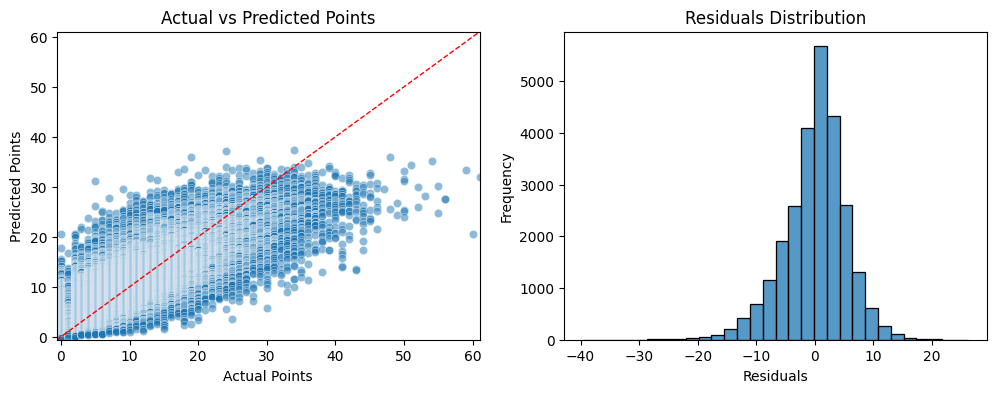

In [9]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Points')
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')

sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()

- Currently my model isnt able to predict games were players score above 30+ points

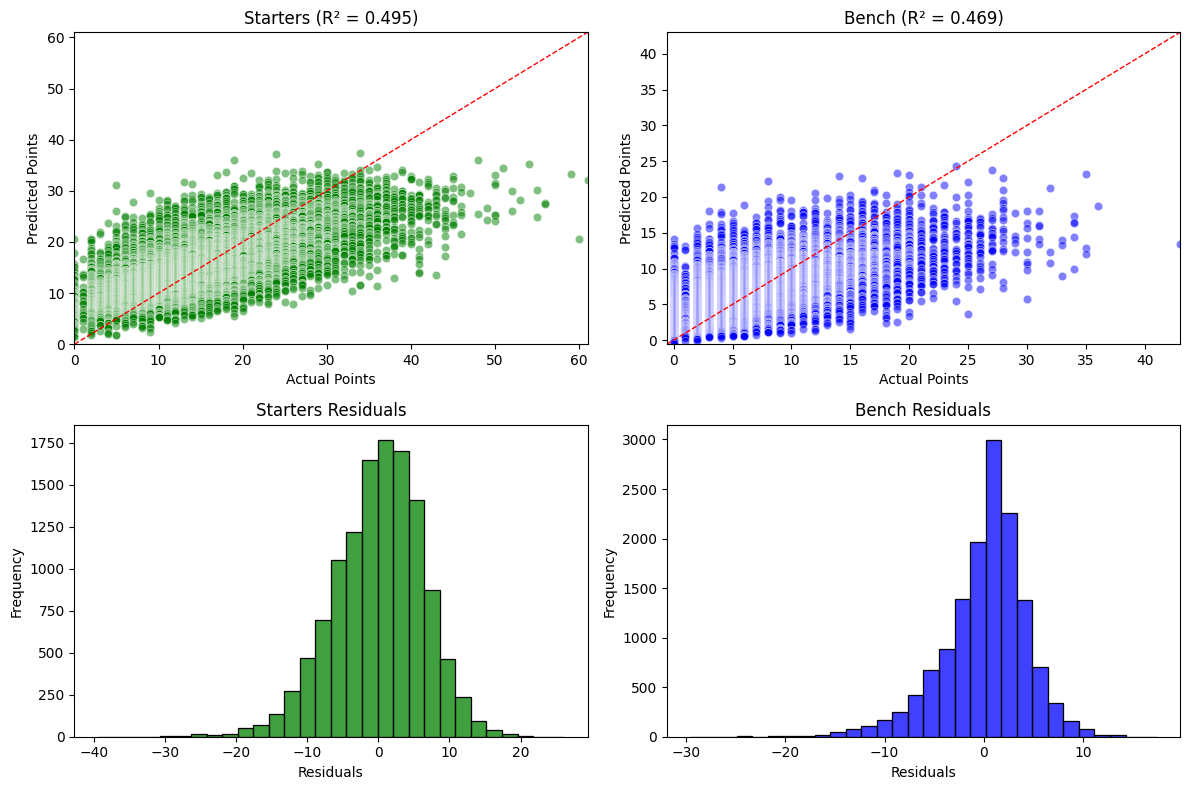

In [10]:
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]
starters_r2 = r2_score(starters['actual'], starters['predicted'])
bench_r2 = r2_score(bench['actual'], bench['predicted'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

sns.scatterplot(x='actual', y='predicted', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['predicted'].min())
maxVal = max(starters['actual'].max(), starters['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Starters (R² = {starters_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['predicted'].min())
maxVal = max(bench['actual'].max(), bench['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Bench (R² = {bench_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starters['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(bench['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()


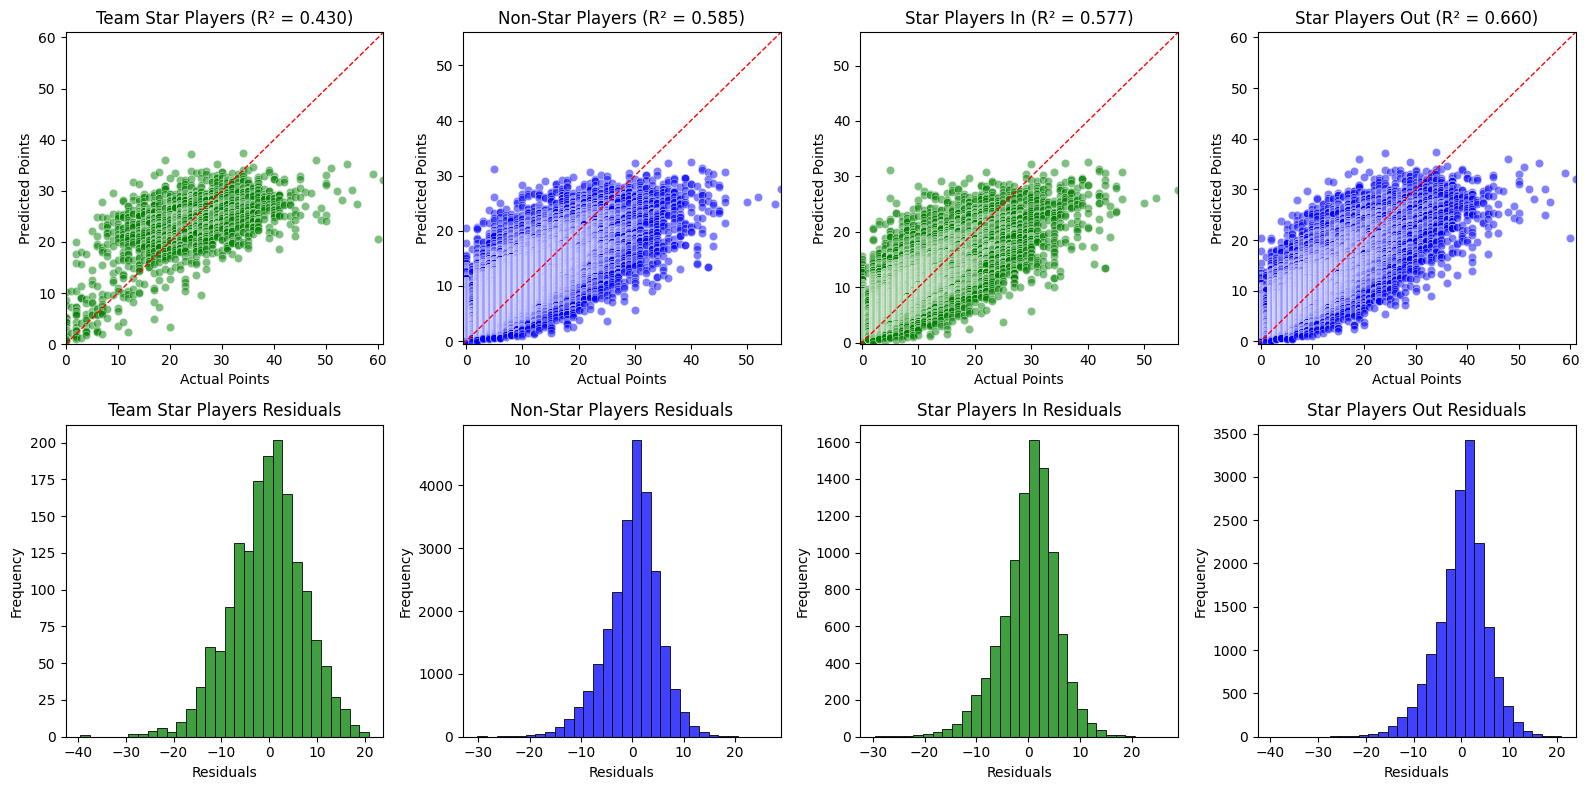

In [11]:
starPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 1]
nonStarPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 0]
star_r2 = r2_score(starPlayers['actual'], starPlayers['predicted'])
nonStar_r2 = r2_score(nonStarPlayers['actual'], nonStarPlayers['predicted'])

starsIn = residuals_df[residuals_df['TEAM_STAR_OUT'] == 1]
starsOut = residuals_df[residuals_df['TEAM_STAR_OUT'] == 0]
starsIn_r2 = r2_score(starsIn['actual'], starsIn['predicted'])
starsOut_r2 = r2_score(starsOut['actual'], starsOut['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Team Star Players
sns.scatterplot(x='actual', y='predicted', data=starPlayers, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starPlayers['actual'].min(), starPlayers['predicted'].min())
maxVal = max(starPlayers['actual'].max(), starPlayers['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Team Star Players (R² = {star_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Non-Star Players
sns.scatterplot(x='actual', y='predicted', data=nonStarPlayers, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(nonStarPlayers['actual'].min(), nonStarPlayers['predicted'].min())
maxVal = max(nonStarPlayers['actual'].max(), nonStarPlayers['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Non-Star Players (R² = {nonStar_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# Star Players In
sns.scatterplot(x='actual', y='predicted', data=starsIn, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(starsIn['actual'].min(), starsIn['predicted'].min())
maxVal = max(starsIn['actual'].max(), starsIn['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'Star Players In (R² = {starsIn_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Star Players Out
sns.scatterplot(x='actual', y='predicted', data=starsOut, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(starsOut['actual'].min(), starsOut['predicted'].min())
maxVal = max(starsOut['actual'].max(), starsOut['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Star Players Out (R² = {starsOut_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(starPlayers['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Team Star Players Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(nonStarPlayers['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Non-Star Players Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(starsIn['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('Star Players In Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(starsOut['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Star Players Out Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

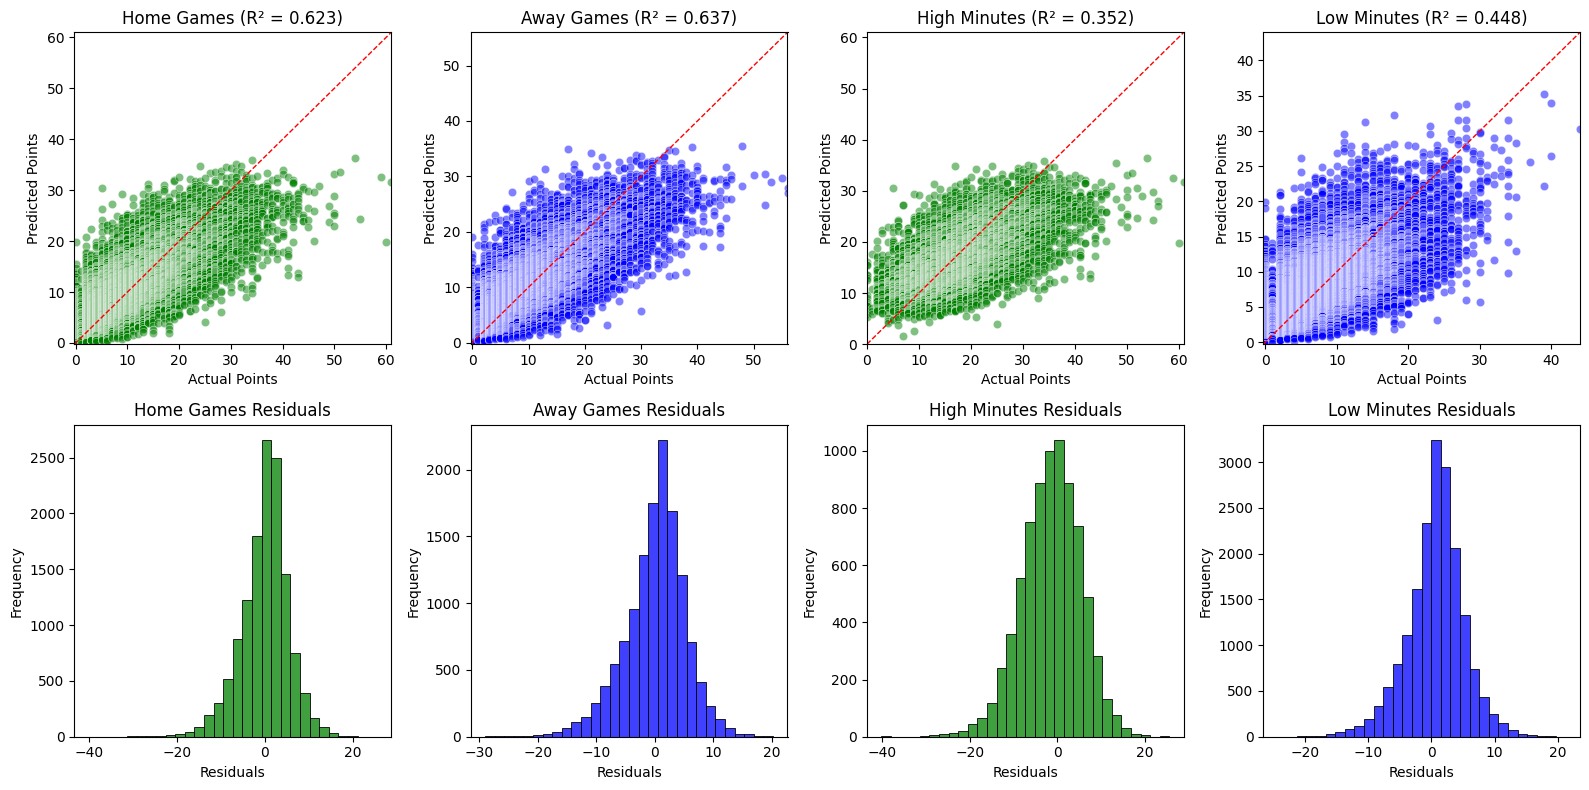

In [18]:
homeGames = residuals_df[residuals_df['HOME_GAME'] == 1]
awayGames = residuals_df[residuals_df['HOME_GAME'] == 0]
homeGames_r2 = r2_score(homeGames['actual'], homeGames['predicted'])
awayGames_r2 = r2_score(awayGames['actual'], awayGames['predicted'])

highMins = residuals_df[residuals_df['MIN'] > 30]
lowMins = residuals_df[residuals_df['MIN'] <= 30]
highMins_r2 = r2_score(highMins['actual'], highMins['predicted'])
lowMins_r2 = r2_score(lowMins['actual'], lowMins['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Home Games
sns.scatterplot(x='actual', y='predicted', data=homeGames, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(homeGames['actual'].min(), homeGames['predicted'].min())
maxVal = max(homeGames['actual'].max(), homeGames['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Home Games (R² = {homeGames_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Away Games
sns.scatterplot(x='actual', y='predicted', data=awayGames, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(awayGames['actual'].min(), awayGames['predicted'].min())
maxVal = max(awayGames['actual'].max(), awayGames['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Away Games (R² = {awayGames_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# High Minutes
sns.scatterplot(x='actual', y='predicted', data=highMins, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(highMins['actual'].min(), highMins['predicted'].min())
maxVal = max(highMins['actual'].max(), highMins['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'High Minutes (R² = {highMins_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Low Minutes
sns.scatterplot(x='actual', y='predicted', data=lowMins, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(lowMins['actual'].min(), lowMins['predicted'].min())
maxVal = max(lowMins['actual'].max(), lowMins['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Low Minutes (R² = {lowMins_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(homeGames['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Home Games Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(awayGames['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Away Games Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(highMins['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('High Minutes Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(lowMins['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Low Minutes Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()